# Chapter 72 — Fitting Simple Models

> **Prerequisites:** ch071 (Modeling), ch058 (Linear Functions)
>
> **You will learn:**
> - Implement least-squares fitting from scratch
> - Understand the geometric interpretation of least squares
> - Fit linear, exponential, and power models
> - Linearize non-linear models for efficient fitting
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Fitting a model** means finding the parameter values that best explain observed data. The standard criterion is **least squares**: minimize the sum of squared residuals.

For y = f(x; θ), we choose θ to minimize:
L(θ) = Σᵢ (yᵢ - f(xᵢ; θ))²

**Linear least squares** has a closed-form solution: θ = (XᵀX)⁻¹Xᵀy
**Non-linear least squares** requires iterative optimization (covered in Part VII).

**Linearization trick:** Many non-linear models can be transformed into linear ones:
- Exponential: y = ae^(bx) → log(y) = log(a) + bx — fit a line to (x, log(y))
- Power: y = axⁿ → log(y) = log(a) + n·log(x) — fit a line to (log(x), log(y))
- This only works when the noise is multiplicative (not additive) — caveat

---

## 2. Intuition & Mental Models

**Physical analogy:** Finding the best-fitting line through scattered points. Least squares minimizes the total "pull" of all points on the line — like a physical spring system where each data point pulls the line toward itself.

**Geometric interpretation:** The least-squares solution projects the observed y vector onto the column space of X. The residual vector (y - Xθ) is perpendicular to the column space. This connects to vectors (Part V) and linear algebra (Part VI).

---

## 3. Visualization

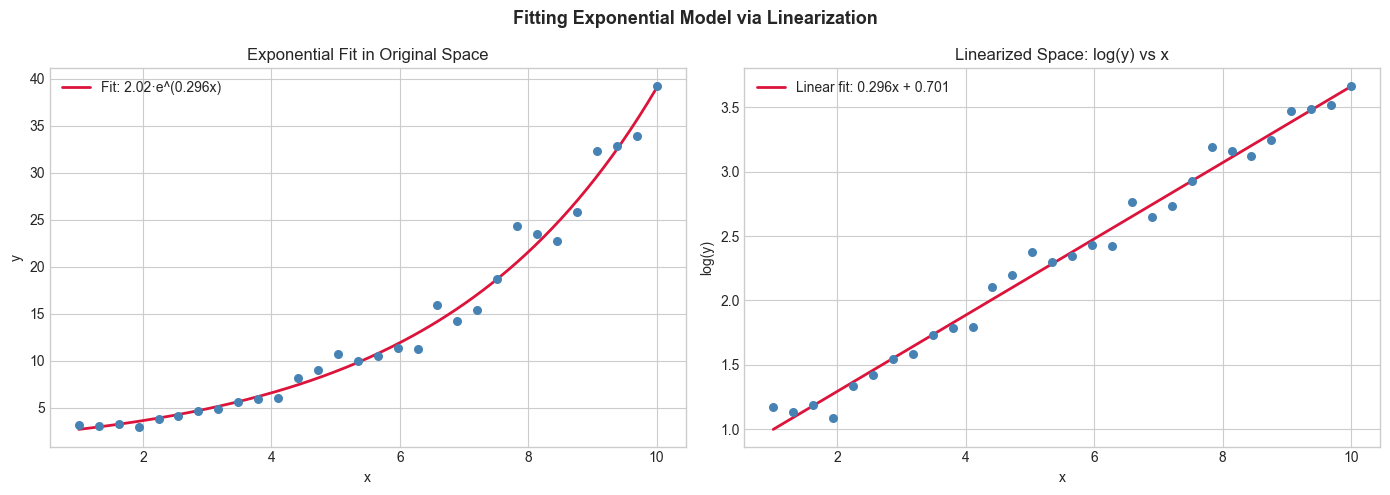

True: a=2, b=0.3 | Fitted: a=2.016, b=0.2963


In [1]:
# --- Visualization: Least squares geometry and linearization ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(3)
x = np.linspace(1, 10, 30)
y_exp = 2 * np.exp(0.3 * x) * np.exp(np.random.normal(0, 0.1, 30))  # multiplicative noise

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original (non-linear) space
axes[0].scatter(x, y_exp, color='steelblue', s=30, zorder=5)
# Fit in log space
log_y = np.log(y_exp)
A = np.column_stack([x, np.ones(len(x))])
b_fit, log_a = np.linalg.lstsq(A, log_y, rcond=None)[0]
x_fine = np.linspace(1, 10, 200)
y_fit = np.exp(log_a) * np.exp(b_fit * x_fine)
axes[0].plot(x_fine, y_fit, color='crimson', linewidth=2,
             label=f'Fit: {np.exp(log_a):.2f}·e^({b_fit:.3f}x)')
axes[0].set_title('Exponential Fit in Original Space')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

# Log-transformed (linear) space
axes[1].scatter(x, log_y, color='steelblue', s=30, zorder=5)
axes[1].plot(x_fine, log_a + b_fit * x_fine, color='crimson', linewidth=2,
             label=f'Linear fit: {b_fit:.3f}x + {log_a:.3f}')
axes[1].set_title('Linearized Space: log(y) vs x')
axes[1].set_xlabel('x'); axes[1].set_ylabel('log(y)'); axes[1].legend()

plt.suptitle('Fitting Exponential Model via Linearization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"True: a=2, b=0.3 | Fitted: a={np.exp(log_a):.3f}, b={b_fit:.4f}")

---

## 5. Python Implementation

In [2]:
# --- Implementation: Multi-model fitter with linearization ---
import numpy as np

def fit_linear(x, y):
    """Fit y = m*x + b. Returns (m, b, R²)."""
    A = np.column_stack([x, np.ones(len(x))])
    coeffs = np.linalg.lstsq(A, y, rcond=None)[0]
    y_hat = A @ coeffs
    r2 = 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)
    return (*coeffs, r2)

def fit_exponential(x, y):
    """Fit y = a*exp(b*x) by linearizing: log(y) = log(a) + b*x."""
    valid = y > 0
    log_y = np.log(y[valid])
    b, log_a, r2 = fit_linear(x[valid], log_y)
    return np.exp(log_a), b, r2

def fit_power(x, y):
    """Fit y = a*x^n by linearizing: log(y) = log(a) + n*log(x)."""
    valid = (x > 0) & (y > 0)
    log_x, log_y = np.log(x[valid]), np.log(y[valid])
    n, log_a, r2 = fit_linear(log_x, log_y)
    return np.exp(log_a), n, r2

# Test on different data types
np.random.seed(0)
x = np.linspace(1, 10, 50)

for name, gen, fitter, fmt in [
    ('linear',      lambda x: 3*x - 1 + np.random.normal(0, 0.5, len(x)),
     fit_linear, lambda r: f"m={r[0]:.3f}, b={r[1]:.3f}, R²={r[2]:.4f}"),
    ('exponential', lambda x: 2*np.exp(0.3*x)*np.exp(np.random.normal(0,.1,len(x))),
     fit_exponential, lambda r: f"a={r[0]:.3f}, b={r[1]:.3f}, R²={r[2]:.4f}"),
    ('power',       lambda x: 5*x**1.5*np.exp(np.random.normal(0,.1,len(x))),
     fit_power, lambda r: f"a={r[0]:.3f}, n={r[1]:.3f}, R²={r[2]:.4f}"),
]:
    y = gen(x)
    result = fitter(x, y)
    print(f"{name}: {fmt(result)}")

linear: m=2.922, b=-0.498, R²=0.9955
exponential: a=1.857, b=0.313, R²=0.9909
power: a=5.271, n=1.482, R²=0.9872


---

## 6. Experiments

**Experiment 1:** Generate y = 3x^1.5 + noise (additive). Try fitting it with fit_power (which assumes multiplicative noise). Compare R² to fit_power on data with multiplicative noise. Which gives better results?

**Experiment 2:** Fit a linear model to polynomial data y = x³ + noise. Plot the residuals. What pattern do you see?

---

## 7. Exercises

**Easy 1.** Use fit_linear to fit y = 2x + 5 with σ=1 noise on 100 points. How close do you get to m=2, b=5?

**Easy 2.** Transform y = 3*2^x into a form that can be fit by linear regression.

**Medium 1.** Implement `fit_polynomial(x, y, degree)` using Vandermonde matrices (np.vander). Test on y = x³ - 2x + 1.

**Medium 2.** Implement cross-validation: split data into 5 folds, fit on 4, evaluate on 1, rotate, average RMSE. Apply to linear vs quadratic fit on noisy cubic data.

**Hard.** Weighted least squares: minimize Σᵢ wᵢ(yᵢ - f(xᵢ))². Implement by noting that Xᵀy → XᵀWy and XᵀX → XᵀWX where W = diag(w). Show this is useful when observations have different reliability (w = 1/σᵢ²).

---

## 9. Chapter Summary & Connections

- Least squares: minimize Σ(y - f(x;θ))² — the universal fitting criterion
- Linear models have closed-form solution θ = (XᵀX)⁻¹Xᵀy
- Linearization: log-transform exponential and power models before fitting
- Linearization assumes multiplicative noise — fails with additive noise

**Forward connections:**
- ch073 (Error and Residuals) analyzes what least squares means geometrically
- ch281 (Regression) extends this to multiple predictors and regularization
- The matrix formula (XᵀX)⁻¹Xᵀy is derived from linear algebra in ch181